# Анализ данных о сердечных заболеваниях
### Задание.

Загрузите из файла *heart.csv* данные о сердечных заболеваниях.

Признаки (переменные):  
- age  
- sex (1 - Male, 0 - Female)  
- cp - chest pain type (4 values)  
- trestbps - resting blood pressure
- chol - serum cholestoral in mg/dl
- fbs - fasting blood sugar > 120 mg/dl
- restecg - resting electrocardiographic results (values 0,1,2)
- thalach - maximum heart rate achieved
- exang - exercise induced angina
- oldpeak - ST depression induced by exercise relative to rest
- slope - the slope of the peak exercise ST segment
- ca - number of major vessels (0-3) colored by flourosopy
- thal - 0 = normal; 1 = fixed defect; 2 = reversable defect

Удалите из датафрейма столбец target и в дальнейшем анализируйте датафрейм без него.

**Ответьте на следующие вопросы и выподните следующие задания:**  

1) Сколько образцов (объектов) содержит данный датасет?  

2) Сколько атрибутов (признаков) содержит данный датасет?  

3) Опишите тип каждого признака: числовой (дискретный/непрерывный), категориальный (номинальный/бинарный/ординальный).

4) Вычислите сколько мужчин/женщин в датасете?  

5) Вычислите описательные статистики для количественных признаков (среднее значение, медиана, мода (только для дискретных переменных), размах, дисперсия, среднеквадратичное отклонение, 1й/2й/3й квартили, межквартильный размах) с помощью numpy или statistics. Создайте единую функцию, которая вычислит все эти значения.

6) Для категориальных признаков определите возможные категории и число объектов, принадлежащих к каждой категории. Для каждого признака постройте соответствующую столбчатую диаграмму. Подпишите оси.

7) Постройте гистограммы для признаков age, trestbps, chol, thalach, oldpeak. Расположите подграфики для гистограмм в одну линию. Подпишите оси каждой гистограммы. Гистограммы должны быть разных цветов.

8) Постройте "ящики с усами" для признаков age, trestbps, chol, thalach, oldpeak. Подпишите оси.

9) Постройте на одном графике две кривые PDF (probability density function) для признака chol. Одна PDF для мужчин, другая - для женщин. Подпишите оси, добавьте легенду.  

10) Сгруппируйте данные по полу и вычислите для каждой группы среднее значение признака chol, применив к датафрейму функцию аггрегации. Изобразите результаты в виде столбчатой диаграммы, где столбцы должены соответствовать полу, а высота столбцов -  ссоответствующим средним значениям признака chol. Добавьте к каждому столбцу планку погрешности, отражающую среднеквадратичное отклонение.  

11) Сделайте различные выводы относительно рассматриваемого датасета.

## 1. Загрузка данных из файла

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'Копия heart.csv'
df = pd.read_csv(file_path)
df.head()

Первые 5 строк датасета:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Удаление столбца target

In [3]:
# Удаляем столбец 'target' из датафрейма
df = df.drop('target', axis=1)
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


## 3. Количество образцов и признаков

In [4]:
# Сколько образцов (объектов) содержит данный датасет?
print(f"Количество образцов (строк) в датасете: {df.shape[0]}")

# Сколько атрибутов (признаков) содержит данный датасет?
print(f"Количество признаков (столбцов) в датасете: {df.shape[1]}")

Количество образцов (строк) в датасете: 303
Количество признаков (столбцов) в датасете: 13


## 4. Типы признаков


| Признак     | Тип                              |
|-------------|----------------------------------|
| `age`       | Числовой, дискретный             |
| `sex`       | Категориальный, бинарный         |
| `cp`        | Категориальный, ординальный      |
| `trestbps`  | Числовой, непрерывный            |
| `chol`      | Числовой, непрерывный            |
| `fbs`       | Категориальный, бинарный         |
| `restecg`   | Категориальный, ординальный      |
| `thalach`   | Числовой, непрерывный            |
| `exang`     | Категориальный, бинарный         |
| `oldpeak`   | Числовой, непрерывный            |
| `slope`     | Категориальный, ординальный      |
| `ca`        | Числовой, дискретный             |
| `thal`      | Категориальный, ординальный      |

- **Числовой, дискретный** — целые числа (например, возраст, количество).
- **Числовой, непрерывный** — вещественные числа (например, давление, холестерин).
- **Категориальный, бинарный** — два значения (например, пол: мужчина/женщина).
- **Категориальный, ординальный** — категории с естественным порядком (например, степень боли: слабая < умеренная < сильная).
- Номинальный признак — это категориальный признак, у которого нет естественного порядка.

## 5. Количество мужчин и женщин

In [6]:
# Сколько мужчин/женщин в датасете?
num_men = (df['sex'] == 1).sum()
num_women = (df['sex'] == 0).sum()
print(f"Мужчин: {num_men}")
print(f"Женщин: {num_women}")

Мужчин: 207
Женщин: 96


## 6. Описательные статистики количественных признаков

In [11]:
# Функция для вычисления описательных статистик количественных признаков
from scipy import stats
def describe_numeric(series):
    stats_dict = {}
    stats_dict['среднее'] = series.mean()
    stats_dict['медиана'] = series.median()
    
    # Мода для дискретных
    if pd.api.types.is_integer_dtype(series):  # Проверяем, что это целочисленный тип
        mode_val = series.mode()
        stats_dict['мода'] = mode_val.iloc[0] if not mode_val.empty else '—'
    else:
        stats_dict['мода'] = '—'
    
    stats_dict['размах'] = series.max() - series.min()
    stats_dict['дисперсия'] = series.var(ddof=1)
    stats_dict['СКО'] = series.std(ddof=1)
    stats_dict['1 квартиль'] = series.quantile(0.25)
    stats_dict['2 квартиль (медиана)'] = series.quantile(0.50)
    stats_dict['3 квартиль'] = series.quantile(0.75)
    stats_dict['межквартильный размах'] = stats_dict['3 квартиль'] - stats_dict['1 квартиль']
    
    return stats_dict

# Признаки для анализа
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

for col in numeric_cols:
    print(f"\nСтатистики для {col}:")
    for k, v in describe_numeric(df[col]).items():
        print(f"{k}: {v}")


Статистики для age:
среднее: 54.366336633663366
медиана: 55.0
мода: 58
размах: 48
дисперсия: 82.48455838961381
СКО: 9.082100989837858
1 квартиль: 47.5
2 квартиль (медиана): 55.0
3 квартиль: 61.0
межквартильный размах: 13.5

Статистики для trestbps:
среднее: 131.62376237623764
медиана: 130.0
мода: 120
размах: 106
дисперсия: 307.5864533473212
СКО: 17.53814281351709
1 квартиль: 120.0
2 квартиль (медиана): 130.0
3 квартиль: 140.0
межквартильный размах: 20.0

Статистики для chol:
среднее: 246.26402640264027
медиана: 240.0
мода: 197
размах: 438
дисперсия: 2686.4267479728114
СКО: 51.830750987930045
1 квартиль: 211.0
2 квартиль (медиана): 240.0
3 квартиль: 274.5
межквартильный размах: 63.5

Статистики для thalach:
среднее: 149.64686468646866
медиана: 153.0
мода: 162
размах: 131
дисперсия: 524.6464057001724
СКО: 22.905161114914087
1 квартиль: 133.5
2 квартиль (медиана): 153.0
3 квартиль: 166.0
межквартильный размах: 32.5

Статистики для oldpeak:
среднее: 1.0396039603960396
медиана: 0.8
мода: —

## 7. Категориальные признаки: категории и распределение


Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64



Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


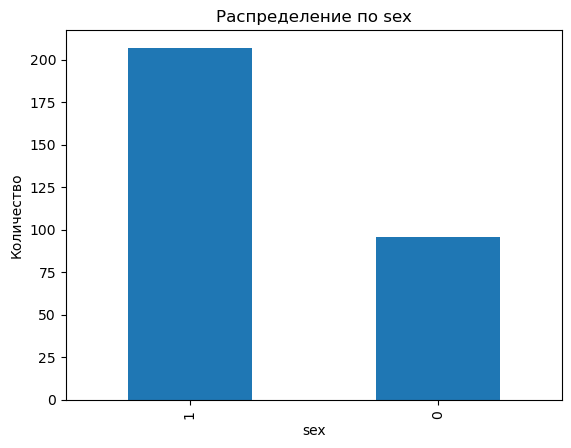


Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


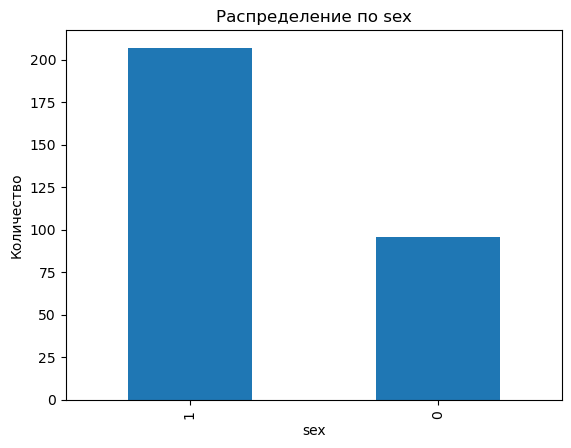


Категориальный признак: cp
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


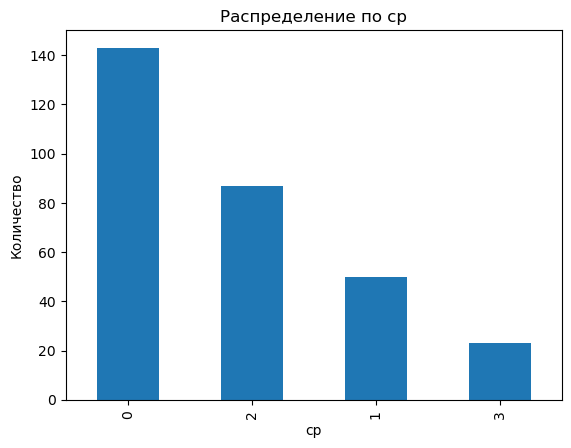


Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


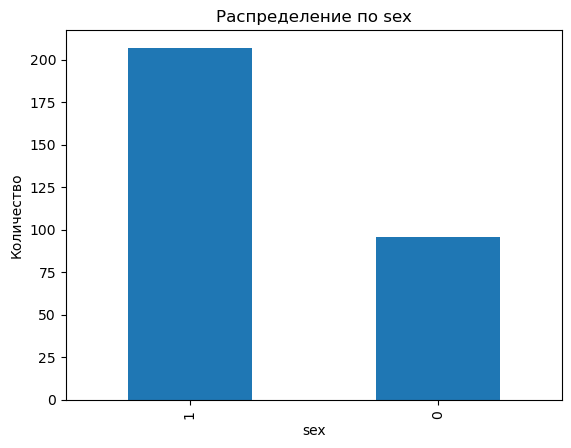


Категориальный признак: cp
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


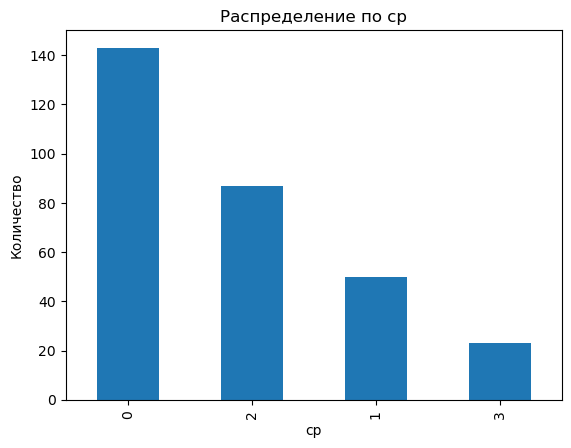


Категориальный признак: fbs
fbs
0    258
1     45
Name: count, dtype: int64



Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


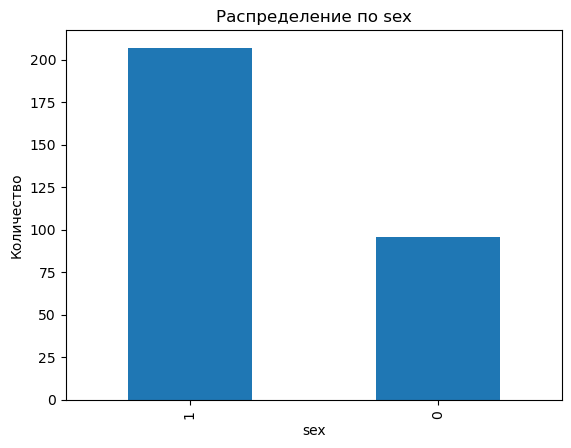


Категориальный признак: cp
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


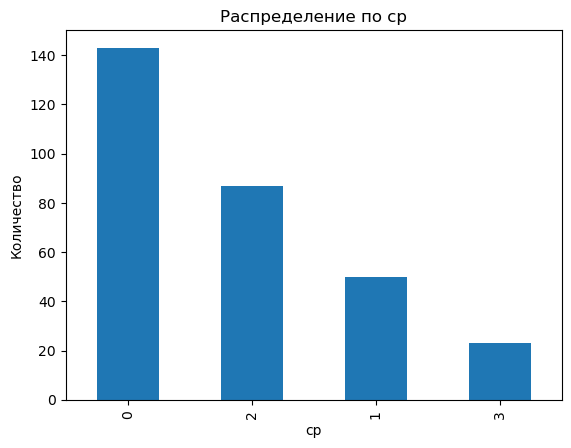


Категориальный признак: fbs
fbs
0    258
1     45
Name: count, dtype: int64


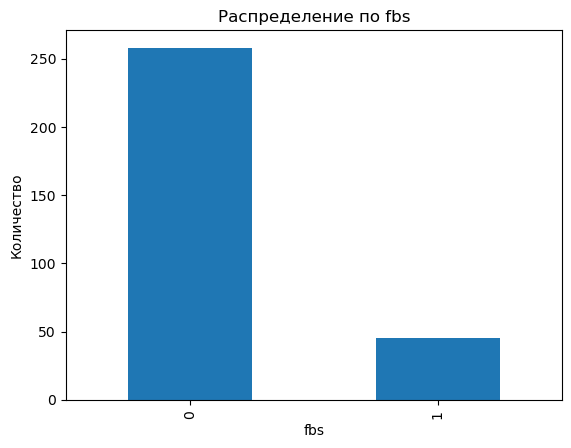


Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


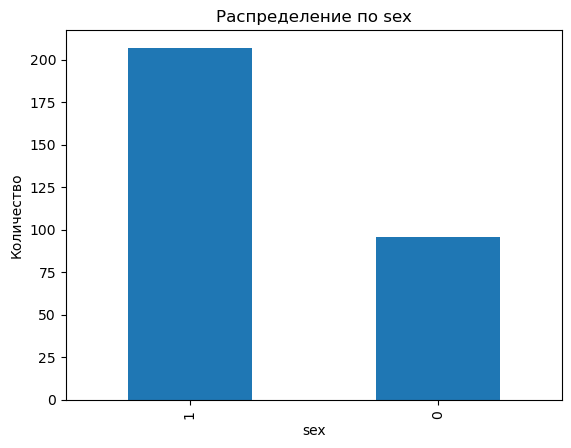


Категориальный признак: cp
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


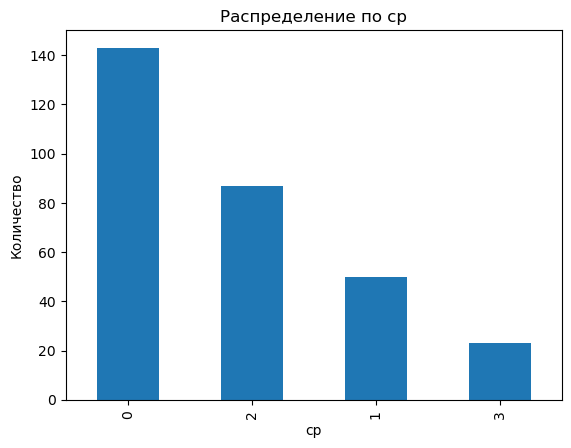


Категориальный признак: fbs
fbs
0    258
1     45
Name: count, dtype: int64


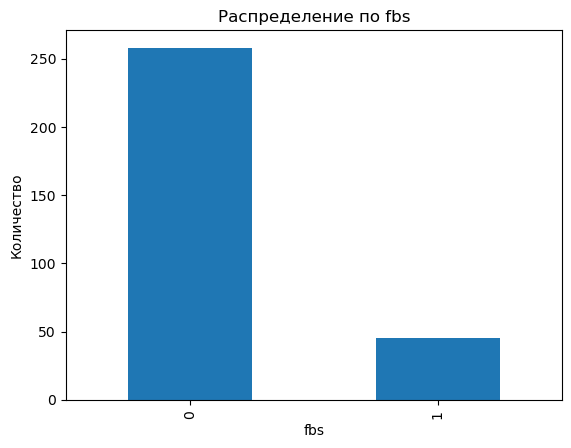


Категориальный признак: restecg
restecg
1    152
0    147
2      4
Name: count, dtype: int64



Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


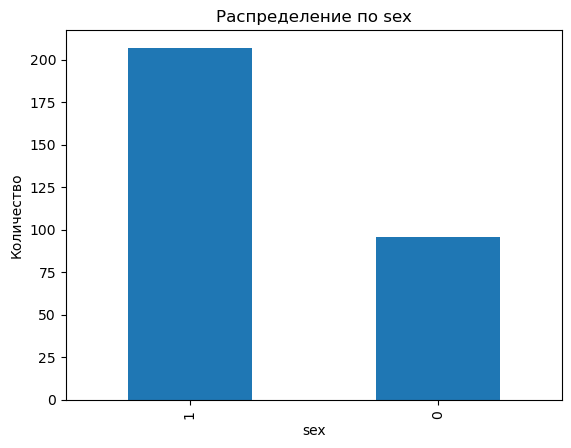


Категориальный признак: cp
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


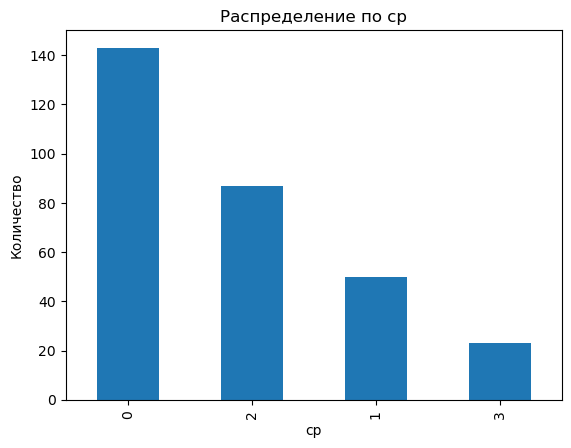


Категориальный признак: fbs
fbs
0    258
1     45
Name: count, dtype: int64


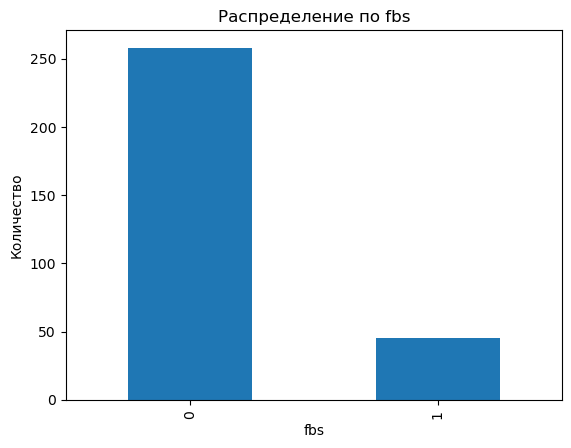


Категориальный признак: restecg
restecg
1    152
0    147
2      4
Name: count, dtype: int64


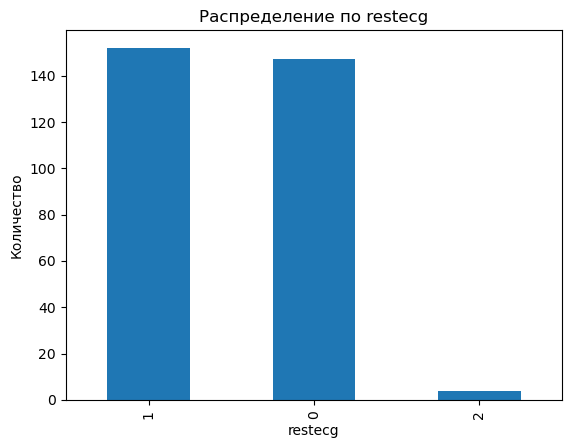


Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


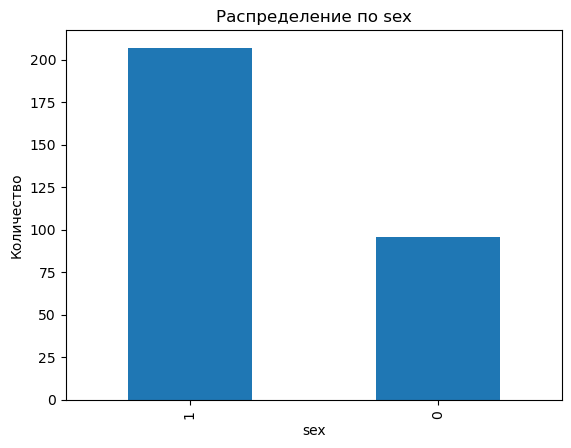


Категориальный признак: cp
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


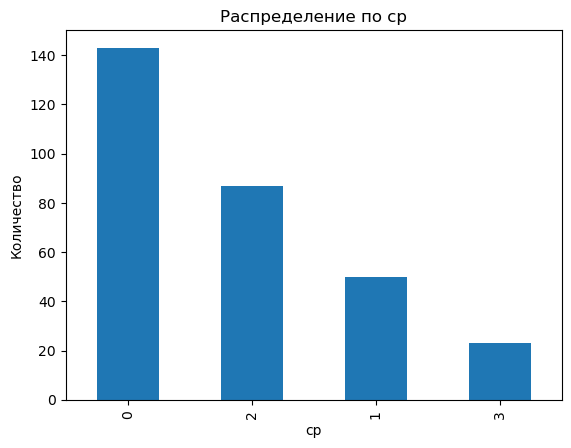


Категориальный признак: fbs
fbs
0    258
1     45
Name: count, dtype: int64


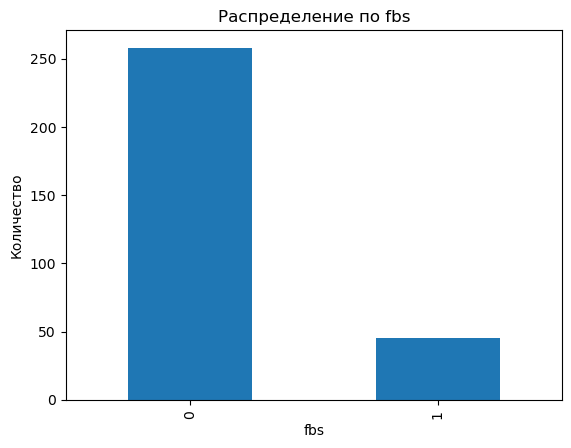


Категориальный признак: restecg
restecg
1    152
0    147
2      4
Name: count, dtype: int64


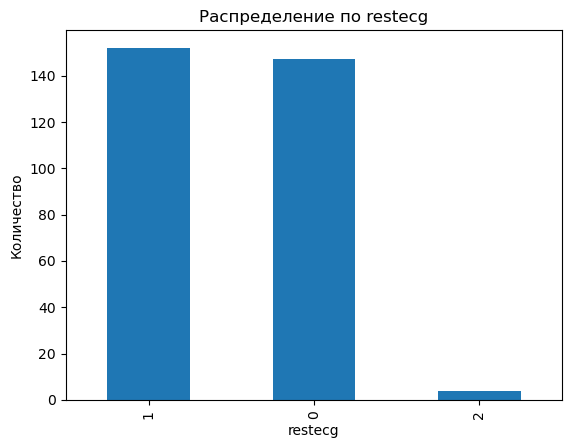


Категориальный признак: exang
exang
0    204
1     99
Name: count, dtype: int64


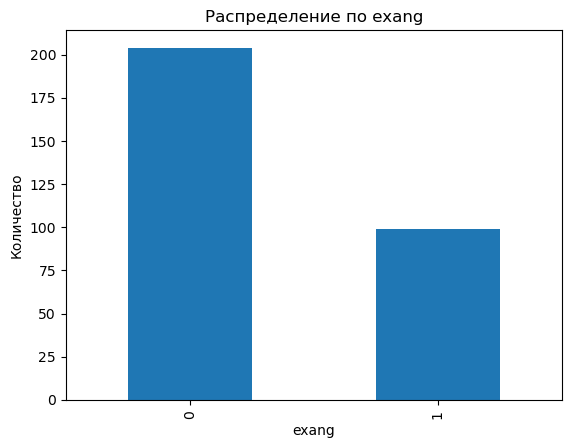


Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


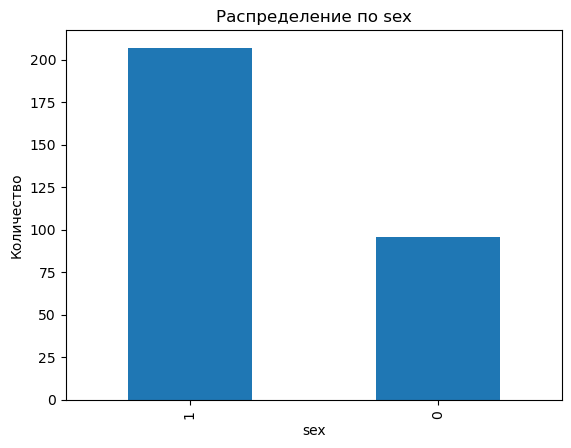


Категориальный признак: cp
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


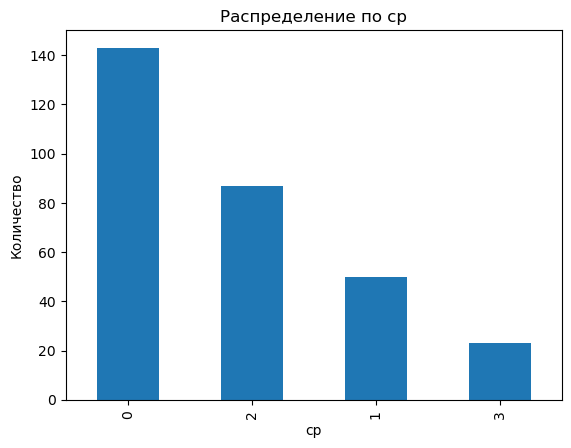


Категориальный признак: fbs
fbs
0    258
1     45
Name: count, dtype: int64


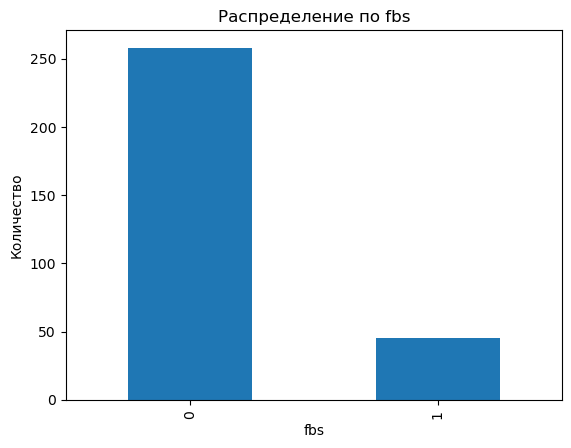


Категориальный признак: restecg
restecg
1    152
0    147
2      4
Name: count, dtype: int64


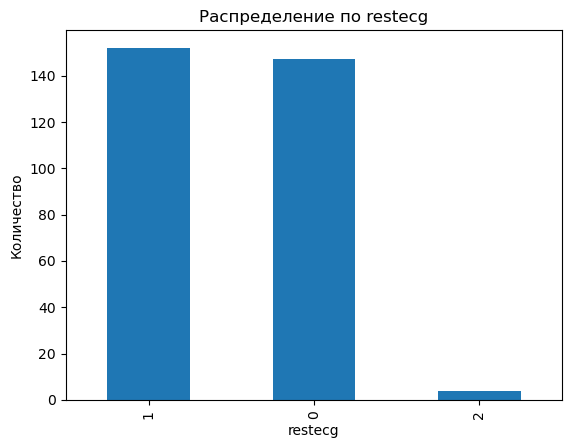


Категориальный признак: exang
exang
0    204
1     99
Name: count, dtype: int64


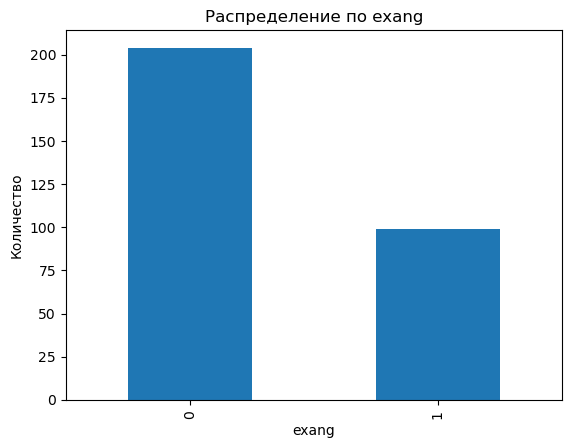


Категориальный признак: slope
slope
2    142
1    140
0     21
Name: count, dtype: int64



Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


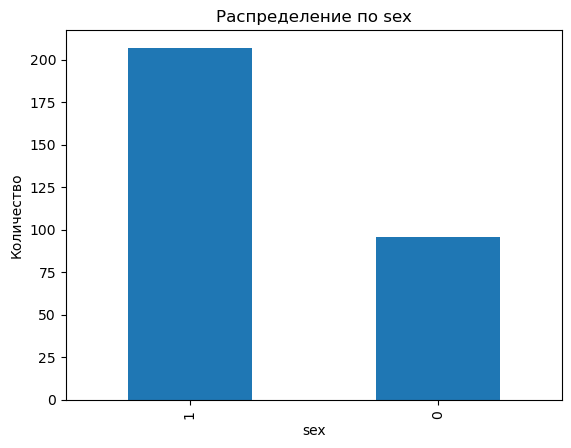


Категориальный признак: cp
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


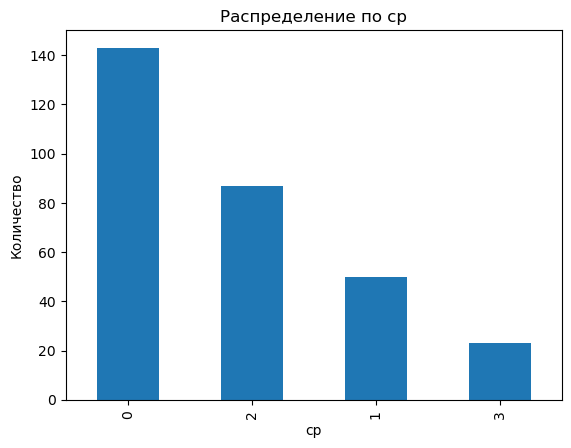


Категориальный признак: fbs
fbs
0    258
1     45
Name: count, dtype: int64


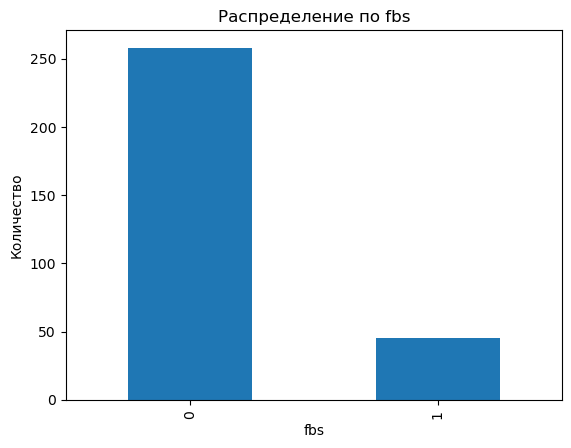


Категориальный признак: restecg
restecg
1    152
0    147
2      4
Name: count, dtype: int64


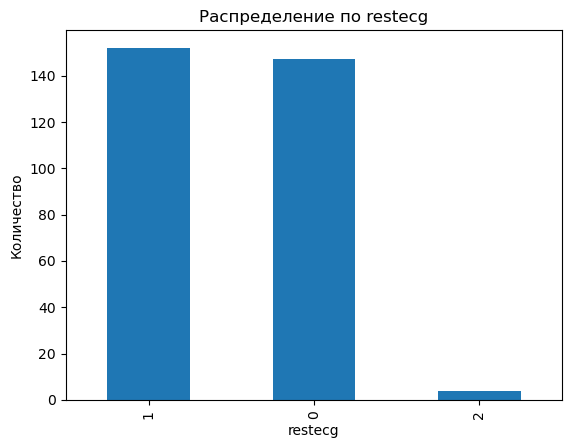


Категориальный признак: exang
exang
0    204
1     99
Name: count, dtype: int64


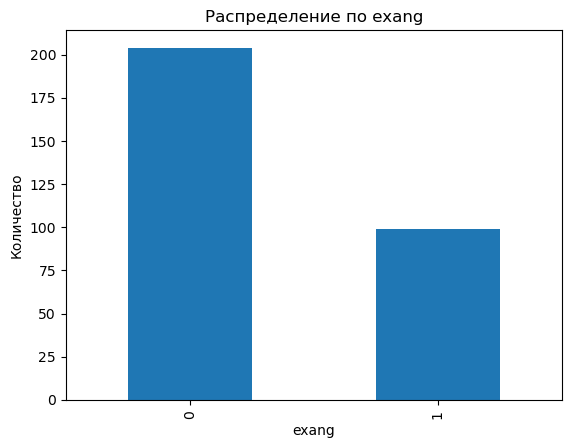


Категориальный признак: slope
slope
2    142
1    140
0     21
Name: count, dtype: int64


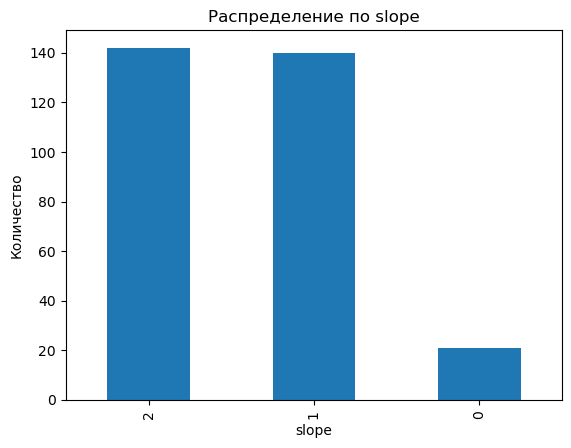


Категориальный признак: thal
thal
2    166
3    117
1     18
0      2
Name: count, dtype: int64



Категориальный признак: sex
sex
1    207
0     96
Name: count, dtype: int64


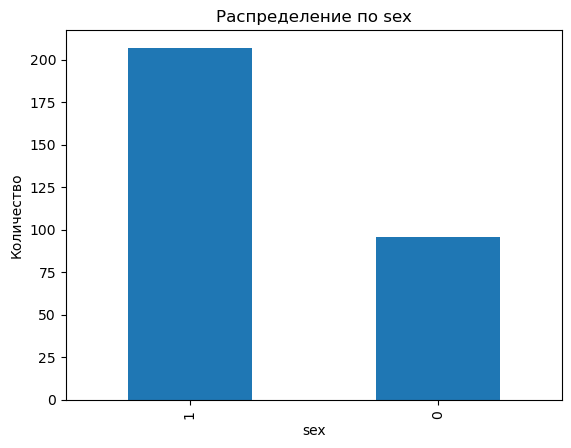


Категориальный признак: cp
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


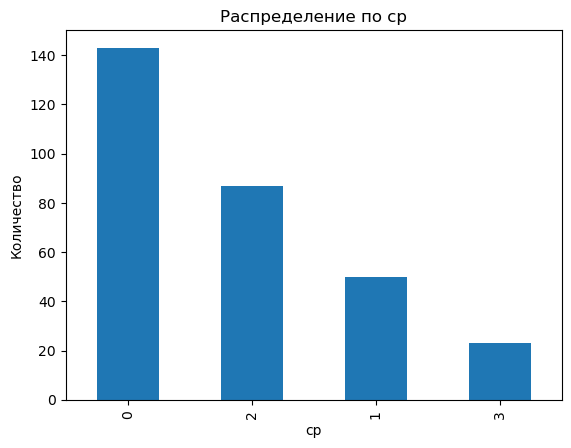


Категориальный признак: fbs
fbs
0    258
1     45
Name: count, dtype: int64


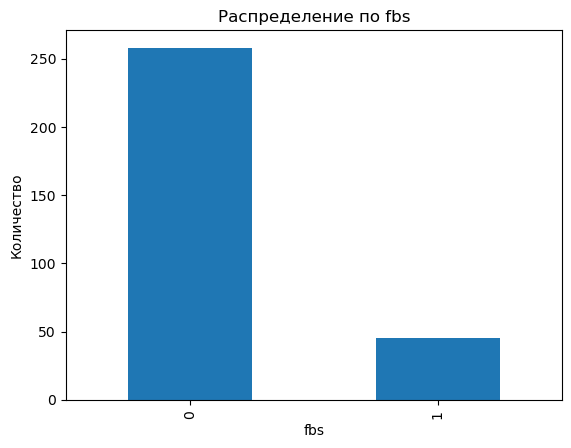


Категориальный признак: restecg
restecg
1    152
0    147
2      4
Name: count, dtype: int64


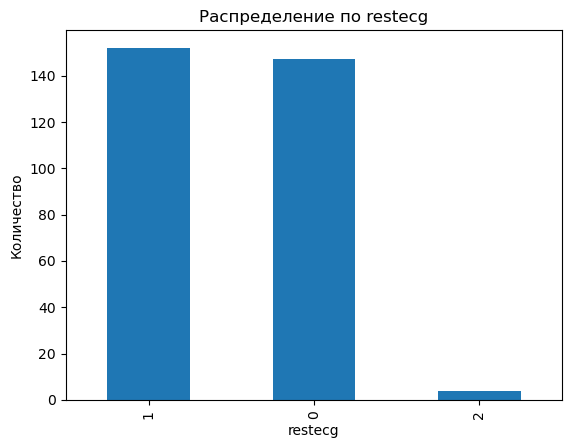


Категориальный признак: exang
exang
0    204
1     99
Name: count, dtype: int64


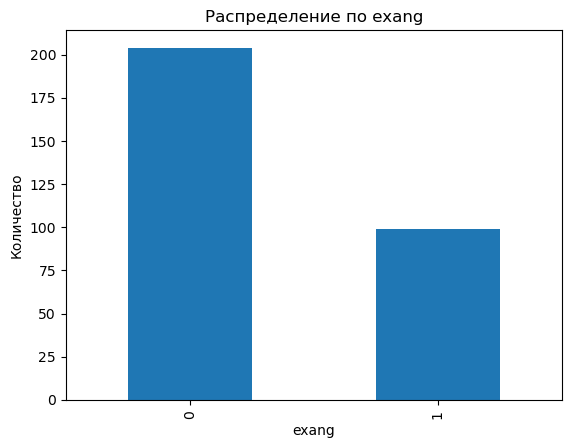


Категориальный признак: slope
slope
2    142
1    140
0     21
Name: count, dtype: int64


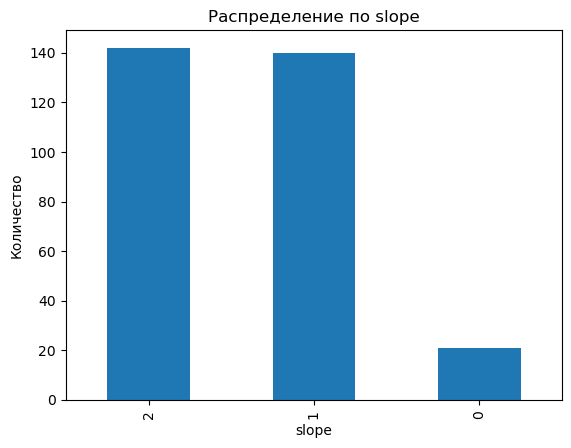


Категориальный признак: thal
thal
2    166
3    117
1     18
0      2
Name: count, dtype: int64


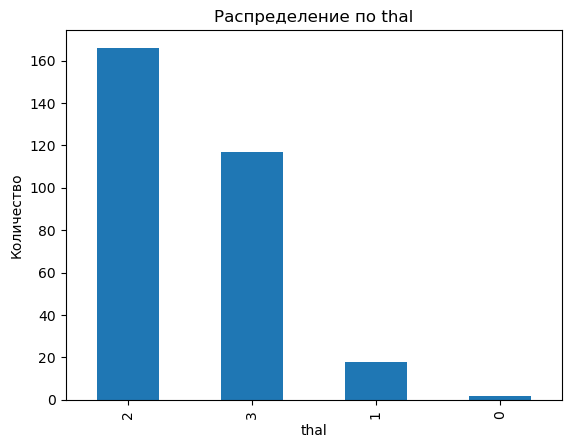

In [12]:
# Для категориальных признаков определим категории и количество объектов в каждой категории
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in cat_cols:
    print(f"\nКатегориальный признак: {col}")
    print(df[col].value_counts())
    # Столбчатая диаграмма
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Распределение по {col}')
    plt.xlabel(f'{col}')
    plt.ylabel('Количество')
    plt.show()

## 8. Гистограммы количественных признаков

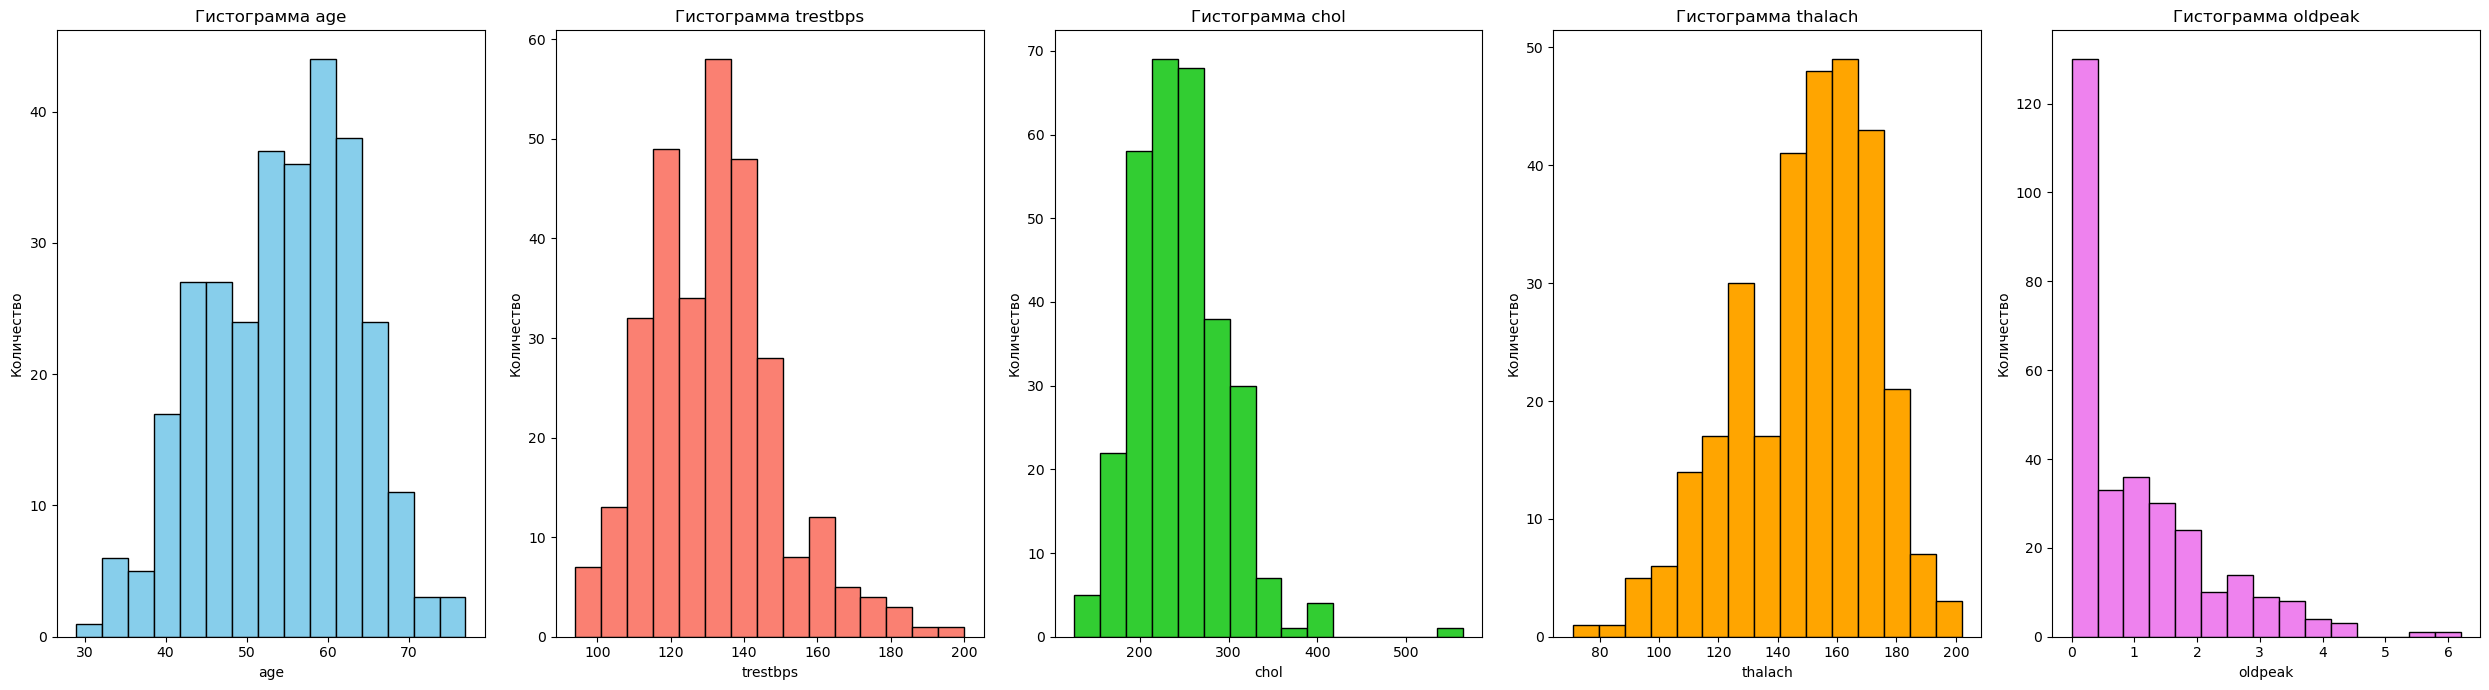

In [15]:
# Гистограммы для признаков age, trestbps, chol, thalach, oldpeak
cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
colors = ['skyblue', 'salmon', 'limegreen', 'orange', 'violet']
plt.figure(figsize=(20, 5))
for i, (col, color) in enumerate(zip(cols, colors)):
    plt.subplot(1, 5, i+1)
    plt.hist(df[col], bins=15, color=color, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.title(f'Гистограмма {col}')
plt.tight_layout()
plt.show()

## 9. Ящики с усами для количественных признаков

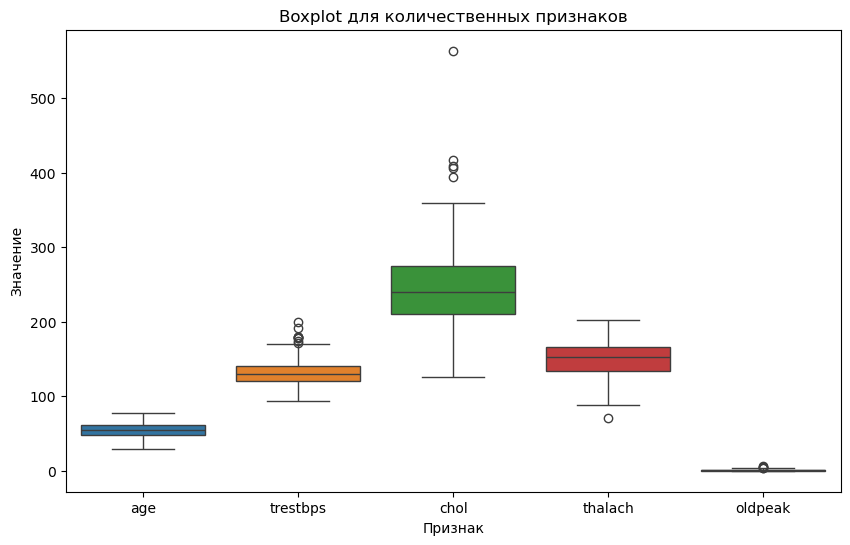

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']])
plt.xlabel('Признак')
plt.ylabel('Значение')
plt.title('Boxplot для количественных признаков')
plt.show()

## 10. PDF для chol: мужчины и женщины

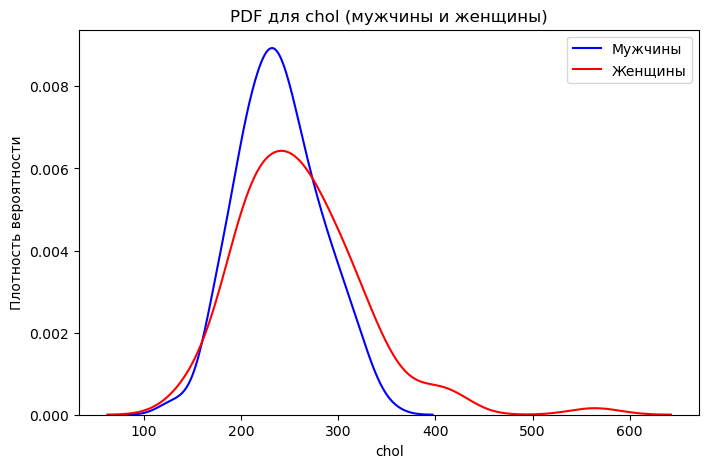

In [17]:
# PDF для chol: мужчины и женщины
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df['sex'] == 1]['chol'], label='Мужчины', color='blue')
sns.kdeplot(df[df['sex'] == 0]['chol'], label='Женщины', color='red')
plt.xlabel('chol')
plt.ylabel('Плотность вероятности')
plt.title('PDF для chol (мужчины и женщины)')
plt.legend()
plt.show()

## 11. Группировка по полу и среднее значение chol с погрешностью

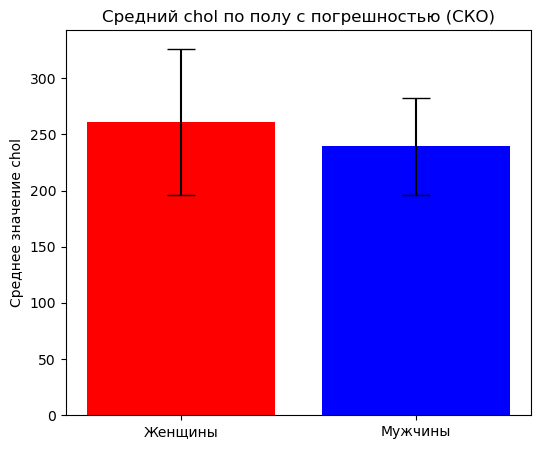

In [18]:
# Группировка по полу и среднее значение chol с погрешностью (СКО)
grouped = df.groupby('sex')['chol']
means = grouped.mean()
stds = grouped.std()

plt.figure(figsize=(6, 5))
plt.bar(['Женщины', 'Мужчины'], means, yerr=stds, color=['red', 'blue'], capsize=10) # последнее это размер черточек
plt.ylabel('Среднее значение chol')
plt.title('Средний chol по полу с погрешностью (СКО)')
plt.show()

## 12. Выводы по датасету

- Датасет содержит информацию о 303 пациентах с 13 признаками (после удаления целевой переменной).
- Среди пациентов больше мужчин (sex=1).
- Распределение возраста близко к нормальному, но есть сдвиг в сторону старшего возраста.
- Уровень холестерина имеет несколько выбросов в большую сторону (видно на boxplot).
- На графике PDF уровня холестерина видны различия в распределениях между мужчинами и женщинами.
- Средний уровень холестерина у женщин выше, чем у мужчин (согласно пункту 10), однако разброс значений также велик.